# Tutorial: Memory/Saving functions

You may have noted that FRETBursts "normalizes" data around the [photon-HDF5](https://photon-hdf5.readthedocs.io) format.
FRETBursts also however extends the use of the more general [HDF5](https://www.hdfgroup.org/solutions/hdf5/)



In [1]:
import numpy as np
import matplotlib.pyplot as plt

import fretbursts as frb

--------------------------------------------------------------
 You are running FRETBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


In [2]:
raw = frb.loadraw.load_spc('../../HDF5/anisotropy/all000apo_SPC630.spc')

TCSPC parameters retrived from the .SET file.


In [3]:
raw.photon_data[0].meas_specs['detectors_specs'].pop('spectral_polarization_split_chN')

array([0, 1, 2, 3], dtype=uint8)

In [4]:
raw.photon_data[0].time_specs['timestamps_unit'] = 5e-8

In [5]:
raw.photon_data[0].nano_specs['tcspc_unit'] = 5e-8/4096
raw.photon_data[0].nano_specs['tcspc_range'] = 5e-8

In [6]:
raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch1'] = np.array([0,1], np.uint8)
raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch2'] = np.array([2,3], np.uint8)
raw.photon_data[0].meas_specs['detectors_specs']['polarization_ch1'] = np.array([1,3], np.uint8)
raw.photon_data[0].meas_specs['detectors_specs']['polarization_ch2'] = np.array([0,2], np.uint8)

In [7]:
raw.setup['detectors']['tcspc_offset'] = np.array([0, 15, 40, 40])

(350.0, 550.0)

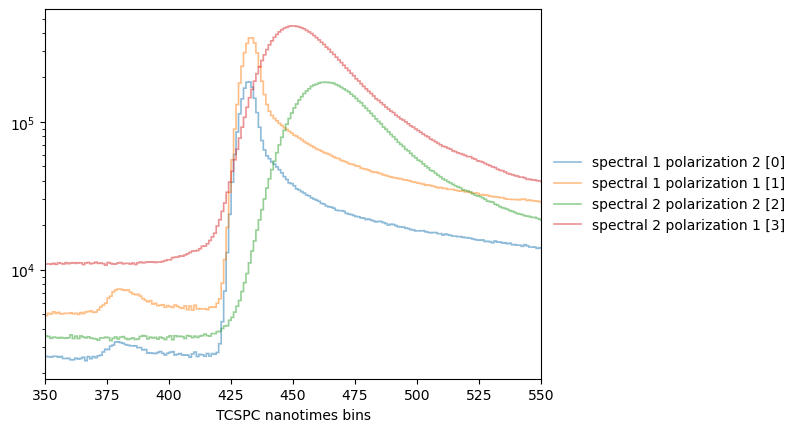

In [8]:
frb.rawplot.alternation_hist(raw)
plt.xlim([350, 550])

In [9]:
raw.photon_data[0].meas_specs['alex_excitation_period1'] = np.array([420, 1920])
raw.photon_data[0].meas_specs['alex_excitation_period2'] = np.array([2235, 3735])

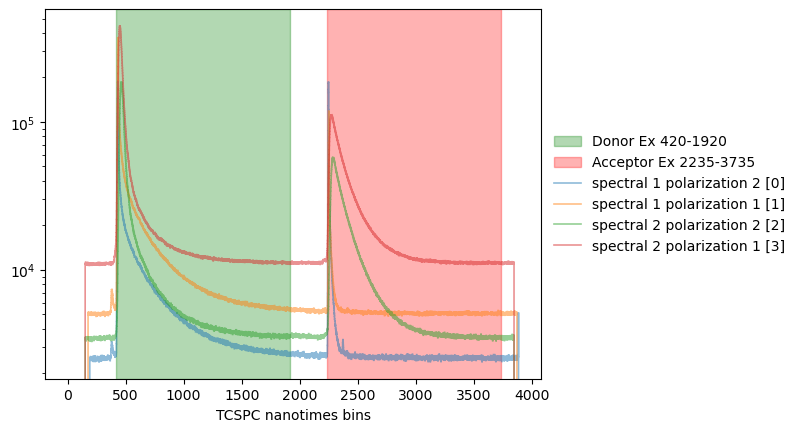

In [10]:
frb.rawplot.alternation_hist(raw)

In [11]:
pd = raw.photon_data[0]

In [12]:
for shift, isect in  frb.datamodel.utils.enumerate_intersects(pd.ems(), pd.pols(), pd.splits()):
    # print(shift, isect)
    pass

(0, 0, 0) [0 0 1]
(0, 1, 0) [0 0 1]
(1, 0, 0) [0 0 1]
(1, 1, 0) [0 0 1]


In [13]:
data = frb.photonHDF5.normalize(raw)

{'clk_p': 5e-08, 'ex_ranges': array([array([[ 420, 1920]]), array([[2235, 3735]])], dtype=object), 'tcspc_unit': array([1.22070312e-11, 1.22070312e-11, 1.22070312e-11, 1.22070312e-11]), 'tcspc_num_bins': array([4096, 4096, 4096, 4096]), 'tcspc_range': 5e-08, 'alex_type': 'nano'}
odets before enumerate [0 4]
split_dets [array([0, 1, 2, 3])]
(0, 0, 0) [2 1 1]
shifting 0 [1]
(0, 1, 0) [2 1 1]
shifting 1 [0]
(1, 0, 0) [2 1 1]
shifting 2 [3]
(1, 1, 0) [2 1 1]
shifting 3 [2]
times [         8146         18353         29546 ... 1431047251445 1431047256316
 1431047271528] int64 148448490


In [15]:
print(frb.BG.__doc__)


    Background rate estimation. Calls ``func(times, clk_p, **params)``
    
    Params
    ------
    compute_stream : str
        How background for multi-stream ph_sel columns is computed.
        Must be one of::
            
            - ``'single'`` compund ph_sel columns always computed as sum of single streams
            - ``'single_all'`` like single, but if ph_sel is *all*, then compute stream separately
            - ``'any'`` all streams computed separately
    func : Callable[[np.ndarray[np.int64], ...], float]
        Callable accepting array of times and outputing background.
    
    Additional params defined by ``func``
    
    
    Parents
    -------
    base : Periods
        The time periods for background calculation.
        
    Columns
    -------
    bg : float, (ph_sel:Ph_sel, )
        background rate for (cnts*s\ :sup:`-1`) ``ph_sel``
    err_KS : float, (ph_sel:Ph_sel, )
        Kolmogorov-Smirnov error metric, computes the error as the max of 
        

In [16]:
frb.bg.exp_mlefit

<function fretbursts.background.exp_mlefit(times: numpy.ndarray[numpy.int64], clk_p: float, tail_min: float = 0.0005, auto_threshold: bool = False, F_bg: float = 2.0) -> float>

In [17]:
frb.make_bg_param?

Signature:
frb.make_bg_param(
    data: fretbursts.photondata.PhotonData,
    tail_min: float = 0.0005,
    period: float = 60.0,
    func: collections.abc.Callable[[numpy.ndarray[numpy.int64], float, ...], float] = <function exp_mlefit at 0x7b6ff44abeb0>,
    **kwargs,
) -> fretbursts.datamodel.tables.Param
Docstring: <no docstring>
File:      ~/Python/fretbursts_new/fretbursts/background.py
Type:      function

In [28]:
prds = frb.Param(frb.Periods, detdef=data.detdef, period=30.0, start_at='time_min', stop_at='over')
bg = frb.Param(frb.BG, base=prds, compute_stream='single_all', func=frb.bg.exp_mlefit, tail_min=5e-4)
burst = frb.Param(frb.Bursts, bg=(bg,), truthtable=np.array([False, True]), m=np.array([10,]), F=np.array([6.0,]), streams=(frb.PhSel('0ex_1ex1em')))

In [29]:
nph = frb.Column(burst, 'nph_raw', frb.PhSel('0ex0em1pol'))

In [30]:
data.get_column(nph)

array([0, 2, 1, ..., 1, 8, 2])

In [31]:
data.get_column(frb.Column(burst, 'nph_raw', frb.PhSel('0ex0em')))

array([ 1,  5,  4, ...,  5, 22, 10])